In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

from tai_localizer.lauralizer import amorphous_model_BHZ_2D as am
from tai_localizer.perulizer import proximity_bonds

from koala.lattice import Lattice
from koala import pointsets
from koala import plotting as pl
import kwant as k

In [2]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

# Part 1

In [3]:
# make the amrphous lattice
L = 5
sigma = 0 * 1 / L
radius = np.sqrt(2) / L - 0.0001

points = pointsets.grid(L, L)
# points = pointsets.move_all_points(points, sigma, sigma, 8)

e, c = proximity_bonds(points, radius)

not_crossing = np.abs(c).sum(axis=1) == 0

lattice = Lattice(points, e[not_crossing], c[not_crossing])

<Axes: >

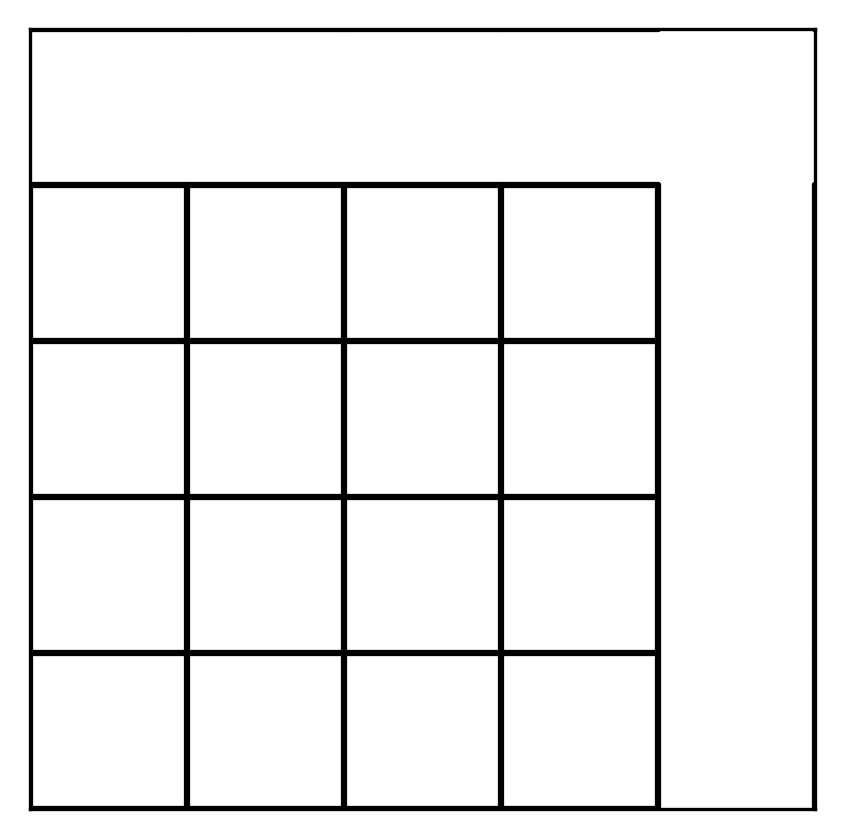

In [4]:
# plot the lattice to check

fig, ax = plt.subplots(figsize=(aps_halfwidth, aps_halfwidth), dpi=300)


ax.set_xticks([])
ax.set_yticks([])

# plt.scatter(*points.T)
pl.plot_edges(lattice)

In [5]:
from tai_localizer.perulizer.misc import sigma_x, sigma_y, sigma_z
from tai_localizer.lauralizer.functions import _fast_pfaffian
from jax.numpy import einsum

import pfaffian as pff

sigma_0 = np.eye(2)


def spectral_localizer_AII2D(
    positions,
    ham,
    E0,
    kappa,
    X0=np.array(["None"]),
    num_reals=50,
    compute_inv=True,
    compute_localgap=False,
    compute_DOS=False,
):
    """Computes the spectral localizer for a 2D AII system.
    ----------------
    syst: kwant object non-finalized,

    Returns
    ----------------
    pfaff_sign: Topological invariant as the sign of the pfaffian."""

    norbs = 4
    Ls = ham.shape[0] // norbs
    x0, y0 = np.average(positions, axis=0)

    X = np.diag(np.kron(positions[:, 0], [1] * 4))
    Y = np.diag(np.kron(positions[:, 1], [1] * 4))

    TR = np.kron(np.kron(np.eye(Ls), sigma_0), sigma_y)
    D = (X - (x0) * np.eye(norbs * Ls)) + 1j * (Y - (y0) * np.eye(norbs * Ls))
    Q = (1 / np.sqrt(2)) * np.block(
        [[np.eye(norbs * Ls), TR], [-TR, np.eye(norbs * Ls)]]
    )
    h = ham - E0 * np.eye(norbs * Ls)

    localizer = np.block([[h, kappa * np.conjugate(D)], [kappa * D, -h]])
    loc_rotated = -np.imag(einsum("ij,jk,kl", Q.conj(), localizer, Q))
    # spec = np.real(pff.pfaffian(loc_rotated, sign_only=True))

    spec = np.sign(_fast_pfaffian(loc_rotated)[0])
    print(spec)
    return

    if compute_inv:
        L = np.block([[h, kappa * np.conjugate(D)], [kappa * D, -h]])

        # pfaff_sign = np.real(pff.pfaffian(Hp,sign_only=True))

        pfaff_sign = np.sign(_fast_pfaffian(Hp, sign_only=True))
        pfaffian_realizations = pfaffian_realizations + pfaff_sign
        list_pf_reals.append(pfaff_sign)
        print("Realization Pfaffian:", np.real(pfaff_sign))

    if compute_localgap:
        L_sparse = np.block([[h, kappa * np.conjugate(D)], [kappa * D, -h]])
        start_time2 = time.perf_counter()
        local_gap = eigsh(L_sparse, k=1, sigma=0)
        print("Local gap realization:", local_gap)
        end_time2 = time.perf_counter()
        print("Time:", end_time2 - start_time2)

        localgap_realization = localgap_realization + np.abs(local_gap)
        list_localgap_realizations.append(np.abs(local_gap))
    # Compute the Density of States of the Localizer with KPM

    if compute_DOS is True:
        start_time2 = time.perf_counter()
        bounds = (-1, 1)
        es = np.linspace(*bounds, 200)
        L_sparse = sp.block([[h, kappa * np.conjugate(D)], [kappa * D, -h]])
        spectrum = kwant.kpm.SpectralDensity(hamiltonian=L_sparse)
        spectrum.add_moments(energy_resolution=0.01)
        energy_subset = es
        density_subset = spectrum(energy_subset)
        DOS = np.real(density_subset) / np.max(np.real(density_subset))
        density_subset_realizations += np.array(DOS)
        # You get local gap for free!
        localgap = find_dos_gap(energy_subset, DOS)
        localgap_realization += localgap
        list_localgap_realizations.append(localgap)
        end_time2 = time.perf_counter()
        print("Time:", end_time2 - start_time2)

    pfaffian_averaged = pfaffian_realizations / num_reals
    localgap_average = localgap_realization / num_reals
    density_subset_average = density_subset_realizations / num_reals

    if compute_inv:
        print("Pfaffian sign:", pfaffian_averaged)
        return pfaffian_averaged, list_pf_reals

    if compute_localgap:
        print("Local gap:", np.abs(localgap_average[0]))
        return localgap_average, list_localgap_realizations

    if compute_DOS is True:
        return (
            energy_subset,
            density_subset_average,
            localgap_average,
            list_localgap_realizations,
        )


def spec_loc_kwant(system, params, kappa, e0, TRS=None):

    fsyst = system.finalized()
    positions = np.array([site.pos for site in fsyst.sites])
    center = np.average(positions, axis=0)
    norbs = 4

    Ls = len(positions)
    if TRS is None:
        TRS = np.kron(np.kron(np.eye(Ls), sigma_0), sigma_y)
    hamiltonian = fsyst.hamiltonian_submatrix(params=params)

    q = np.eye(2 * len(hamiltonian)) + np.kron(sigma_y, TRS)

    h_trs = einsum("ji,jk,kl -> il", TRS, hamiltonian, TRS)
    assert np.allclose(h_trs, hamiltonian.conj()), "System doesn't have TRS symmetry"

    X = np.kron(np.diag(positions[:, 0] - center[0]), np.eye(norbs))
    Y = np.kron(np.diag(positions[:, 1] - center[1]), np.eye(norbs))

    naive_localiser = (
        np.kron(sigma_x, X) * kappa
        + np.kron(sigma_y, Y) * kappa
        + np.kron(sigma_z, hamiltonian - e0 * np.eye(len(hamiltonian)))
    )
    rotated_localiser = -einsum("ji,jk,kl -> il", q.conj(), naive_localiser, q)
    loc = rotated_localiser.imag
    pf = _fast_pfaffian(loc)
    print(pf)

    return np.sign(pf[0])

In [11]:
from tai_localizer.lauralizer.amorphous_model_BHZ_2D import amorph_BHZ
import tai_localizer
from importlib import reload
reload(tai_localizer.lauralizer.localizer)
from tai_localizer.lauralizer.localizer import spectral_localizer_AII2D

system = amorph_BHZ(points * L, e[not_crossing])


def parameters_to_observables(system, A, B, Delta, dis_onsite, dis_hadamard):

    rng = np.random.default_rng()
    par_dict = {
        "norbs": 4,
        "rng_hdmd": rng,
        "Delta": Delta,
        "dis_hadamard": dis_hadamard * 100,
        "mu": 0,
        "A": A,
        "B": B,
        "rng_W": rng,
        "dis_onsite": dis_onsite,
    }
    fsyst = system.finalized()
    ham = fsyst.hamiltonian_submatrix(params=par_dict)
    positions = [site.pos for site in fsyst.sites]
    print(spectral_localizer_AII2D(np.array(positions),ham,0,0.1))


seed_onsite = 0
seed_hadamard = 0
rng_W = np.random.default_rng(int(seed_onsite))
rng_hdmd = np.random.default_rng(int(seed_hadamard))
Delta = 2.0
B = 1
A = 1
dis_onsite = 0


x = parameters_to_observables(system, A, B, Delta, dis_onsite, 1)


# check its right
# k.plot(system)
# plt.show()

-1.0
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 2120 stored elements and shape (200, 200)>
  Coords	Values
  (0, 123)	(0.4999999999999999+0j)
  (0, 100)	(-0.19999999999999998+0j)
  (0, 101)	(-1.9999999999999996+0j)
  (0, 1)	(0.19999999999999998+0j)
  (0, 105)	(0.9999999999999998+0j)
  (0, 7)	(0.4999999999999999+0j)
  (0, 121)	(0.9999999999999998+0j)
  (0, 23)	(3.0616169978683824e-17+0j)
  (1, 101)	(-0.19999999999999998+0j)
  (1, 100)	(1.9999999999999996+0j)
  (1, 0)	(-0.19999999999999998+0j)
  (1, 104)	(-0.9999999999999998+0j)
  (1, 6)	(0.4999999999999999+0j)
  (1, 120)	(-0.9999999999999998+0j)
  (1, 122)	(-0.4999999999999999+0j)
  (1, 22)	(3.0616169978683824e-17+0j)
  (2, 107)	(-0.9999999999999998+0j)
  (2, 5)	(0.4999999999999999+0j)
  (2, 123)	(-0.9999999999999998+0j)
  (2, 121)	(-0.4999999999999999+0j)
  (2, 21)	(3.0616169978683824e-17+0j)
  (2, 102)	(-0.19999999999999998+0j)
  (2, 103)	(1.9999999999999996+0j)
  (2, 3)	(0.19999999999999998+0j)
  (3, 120)	(0.499

/Users/laura/Desktop/TAI-localizer/src/tai_localizer/lauralizer/functions.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  matrix_f = np.asarray(K, dtype=np.float64, order="F")


TypeError: object of type 'NoneType' has no len()

<Figure size 640x480 with 0 Axes>

# Part 2

In [ ]:
np.eye(10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])